# Empirical Distributions

In data science, the word "empirical" means "observed." Empirical distributions are distributions of observed data, such as data in random samples.

In this section we will generate data and examine what empirical distributions look like.

Our setting is a simple experiment: rolling a die multiple times and tracking which face appears. The DataFrame `die` contains the six faces of a fair die.

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

In [2]:
die = pd.DataFrame({"Face": np.arange(1, 7)})
die

,Face
0,1
1,2
2,3
3,4
4,5
5,6


## A Probability Distribution

The histogram below helps visualize the fact that each face appears with probability 1/6. We say that the histogram displays the *distribution* of probabilities across the possible outcomes. Because all faces have the same probability, the distribution is *uniform* on the integers 1 through 6.

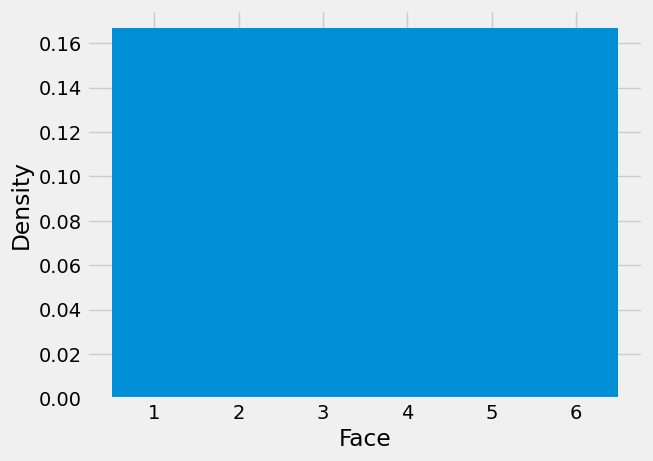

In [3]:
die_bins = np.arange(0.5, 6.6, 1)
die["Face"].plot.hist(bins=die_bins, density=True)
plt.xlabel("Face")
plt.ylabel("Density")
plt.show()

Variables whose values are separated by a fixed amount, such as die rolls, are called **discrete** variables. The histogram above is therefore a *discrete histogram*. The bins are chosen so that each bar is centered on an integer outcome.

The die cannot show 1.3 or 5.2 spots; it always lands on an integer. However, histograms represent probability using areas of bars.

Since each face has probability 1/6 (about 16.67%), and each bin has width 1, the area of each bar corresponds to approximately 16.67% of the total probability.

## Empirical Distributions

The distribution above is a **probability distribution**. It is theoretical and does not require any actual rolls of a die.

An **empirical distribution**, on the other hand, is based on observed data. Empirical distributions are visualized with empirical histograms.

We will generate data by simulating die rolls. Sampling with replacement from the values 1 through 6 is equivalent to repeatedly rolling a fair die.

Here are the results of 10 simulated rolls.

In [4]:
die.sample(n=10, replace=True)

,Face
4,5
1,2
2,3
4,5
2,3
0,1
1,2
4,5
4,5
5,6


We can simulate as many rolls as we like. To make repeated experiments easier, we define a function that simulates a specified number of rolls and draws an empirical histogram of the results.

In [5]:
def empirical_hist_die(n):
    rolls = die.sample(n=n, replace=True)
    rolls["Face"].plot.hist(bins=die_bins, density=True)
    plt.xlabel("Face")
    plt.ylabel("Density")
    plt.title(f"Empirical Histogram of {n} Die Rolls")
    plt.show()

## Empirical Histograms

Here is an empirical histogram based on 10 simulated rolls. It does not necessarily resemble the theoretical distribution very closely. Run the cell multiple times to see how much it varies.

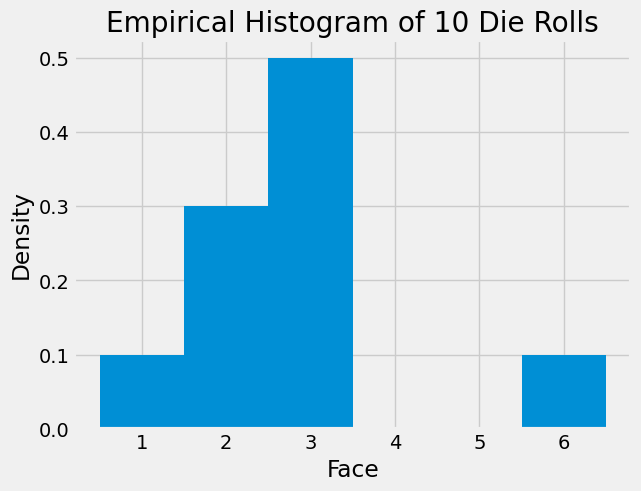

In [6]:
empirical_hist_die(10)

As the sample size increases, the empirical histogram begins to resemble the theoretical probability distribution more closely.

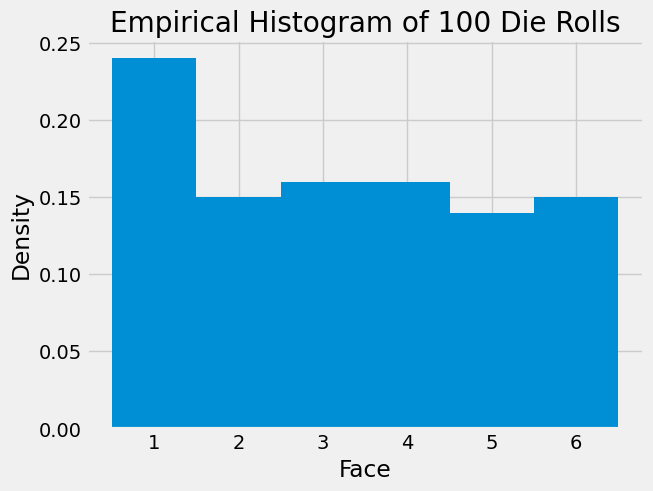

In [7]:
empirical_hist_die(100)

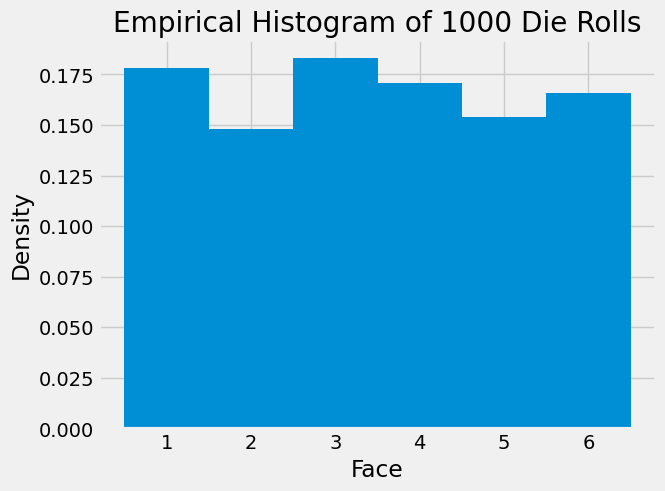

In [8]:
empirical_hist_die(1000)

As the number of simulated rolls increases, the proportion of observations in each category approaches 1/6.

## The Law of Averages

What we have observed is an example of the **law of averages**:

> If a chance experiment is repeated independently and under identical conditions, then in the long run the proportion of times that an event occurs gets closer and closer to the theoretical probability of the event.

For example, in the long run, the proportion of rolls that land on 4 gets closer and closer to 1/6.

"Independently and under identical conditions" means that each repetition is carried out in the same way and is unaffected by previous results.

Under these conditions, if the experiment is repeated a large number of times, the observed proportions are very likely to be close to the theoretical probabilities.